In [1]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.io import fits
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "bold",
    'font.size': 25,
    'font.weight': 'normal',
    
    # Tick direction and appearance
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,            # show top ticks
    'ytick.right': True,          # show right ticks
    'xtick.minor.visible': True,  # show minor x ticks
    'ytick.minor.visible': True,  # show minor y ticks
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    
    # Axes and line properties
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
# Pandas configuration
pd.set_option('display.max_columns', None)

Redshifts for a number of MMT/Hectospec spectra were re-measured using RVSNUpy (Kim et al. 2025) because the original MMT pipeline values were unreliable for those objects. The catalog was updated with the new redshifts where the re-measurements were deemed reliable.

# 1. RVSNUpy Redshift Measure and Update

In [2]:
df = pd.read_csv('./A2199_mastercat_intermediate_file1_flag_update.csv')

In [3]:
# import os
# import pandas as pd

# # RVSNUpy
# os.environ["rvsnupy"] = "/Users/jonginpark/my_tools/RVSNUpy"

# from RVSNUpy.template import sdss_galaxy_templates, zp_calib
# from RVSNUpy.rvm import rvm
# from RVSNUpy.spectrum_import import MMT_raw  # 필요 시 MMT_flux / MMT_raw

# SPECTRA_DIR = (
#     "/Users/jonginpark/sohnix/Research_Archive/2026/Park2026a-A2199-LF/"
#     "DATA/A2199/z_A2199_Hwang/z_SPECTRA/skysub_a2199a19_1"
# )
# Z_OUT_DIR = (
#     "./z_A2199_Hwang"  # z_result.txt 저장 위치 (원하면 변경)
# )

# sub = df[df["z_mmt_z"] != -9].copy()

# def resolve_spec_path(z_filename):
#     if pd.isna(z_filename):
#         return None
#     name = str(z_filename).strip()
#     if not name:
#         return None
#     base = os.path.basename(name)
#     full = os.path.join(SPECTRA_DIR, base)
#     return full if os.path.isfile(full) else None

# sub["_spec_path"] = sub["z_filename"].map(resolve_spec_path)
# found = sub.dropna(subset=["_spec_path"])

# # 존재하는 파일만, 순서 유지하며 중복 제거
# SpecFiles = list(dict.fromkeys(found["_spec_path"].tolist()))

# print(f"rows with z_mmt_z != -9: {len(sub)}")
# print(f"files found under SPECTRA_DIR: {len(SpecFiles)}")

# if not SpecFiles:
#     raise SystemExit("No spectra found — check z_filename basename vs files in folder.")

# gal_temps = zp_calib(sdss_galaxy_templates("vacuum"))
# measure = rvm(gal_temps)

# # measure.z_multi(SpecFiles, MMT_raw)
# measure.z_multi(SpecFiles, MMT_raw, directory=Z_OUT_DIR)

In [4]:
import pandas as pd

path = "./z_A2199_Hwang/z_result.txt"

rvsnupy_result = pd.read_csv(
    path,
    sep=r"\s+",
    engine="python",
    comment="#",
)

# 타입 정리 (선택)
num_cols = ["z", "zerr", "r", "chi_eff"]
for c in num_cols:
    rvsnupy_result[c] = pd.to_numeric(rvsnupy_result[c], errors="coerce")

rvsnupy_result.head()

,spectrum_path,besttemp,z,zerr,r,chi_eff
0,/Users/jonginpark/sohnix/Research_Archive/2026...,Luminous_red_galaxy,0.279382,0.000143,6.975044,1.254619
1,/Users/jonginpark/sohnix/Research_Archive/2026...,No_template,-9.000000,-9.000000,-9.000000,-9.000000
2,/Users/jonginpark/sohnix/Research_Archive/2026...,Late_type_galaxy,0.567644,0.000081,11.678342,1.035281
3,/Users/jonginpark/sohnix/Research_Archive/2026...,Early_type_galaxy,0.031439,0.000180,5.312541,1.078187
4,/Users/jonginpark/sohnix/Research_Archive/2026...,Late_type_galaxy,0.298028,0.000095,18.744322,1.829938


In [5]:
rvsnupy_result

,spectrum_path,besttemp,z,zerr,r,chi_eff
0,/Users/jonginpark/sohnix/Research_Archive/2026...,Luminous_red_galaxy,0.279382,0.000143,6.975044,1.254619
1,/Users/jonginpark/sohnix/Research_Archive/2026...,No_template,-9.000000,-9.000000,-9.000000,-9.000000
2,/Users/jonginpark/sohnix/Research_Archive/2026...,Late_type_galaxy,0.567644,0.000081,11.678342,1.035281
3,/Users/jonginpark/sohnix/Research_Archive/2026...,Early_type_galaxy,0.031439,0.000180,5.312541,1.078187
4,/Users/jonginpark/sohnix/Research_Archive/2026...,Late_type_galaxy,0.298028,0.000095,18.744322,1.829938
...,...,...,...,...,...,...
176,/Users/jonginpark/sohnix/Research_Archive/2026...,Late_type_galaxy,0.356830,0.000033,17.057200,0.968631
177,/Users/jonginpark/sohnix/Research_Archive/2026...,Luminous_red_galaxy,0.251991,0.000112,5.753844,0.996750
178,/Users/jonginpark/sohnix/Research_Archive/2026...,Luminous_red_galaxy,0.332825,0.000090,11.094997,0.989511
179,/Users/jonginpark/sohnix/Research_Archive/2026...,Luminous_red_galaxy,0.332634,0.000169,6.088542,0.998449


=== z (RVSNUpy) vs z_mmt_z (MMT) ===
N valid pairs     : 151
mean(Δz)          : -0.001248
std(Δz)           : 0.029686
median(Δz)        : -0.000290
MAD(Δz)           : 0.000155
σ_NMAD (robust)   : 0.000230
rms(Δz)           : 0.029614
max|Δz|           : 0.338831


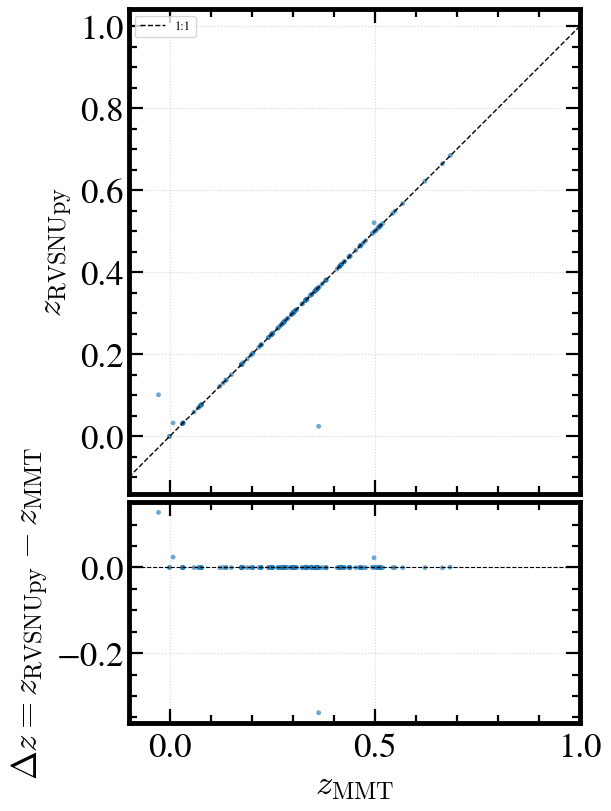

In [6]:
import os
import pandas as pd

def file_basename(x):
    if pd.isna(x):
        return None
    return os.path.basename(str(x).strip())

# rvsnupy_result: spectrum_path → 파일명
r = rvsnupy_result.copy()
r["_match"] = r["spectrum_path"].map(file_basename)

# df: z_filename → 같은 기준 파일명
d = df.copy()
d["_match"] = d["z_filename"].map(file_basename)

# 같은 파일명이 df에 여러 번 있으면 merge 시 행이 늘어남 → 첫 행만 유지
d = d.drop_duplicates(subset="_match", keep="first")

# rvsnupy_result 행 수 보존 (left)
out = r.merge(d, on="_match", how="left", suffixes=("", "_from_df"))

out = out.drop(columns=["_match"])

# out이 최종 테이블 (rvsnupy_result 한 줄당 한 줄)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 유효 데이터 (MMT 플레이스홀더 -9 등 제외 — 필요에 맞게 조정)
def valid_z_pair(df, zcol="z", zref="z_mmt_z", bad=(-9.0, -99.0, np.nan)):
    a = pd.to_numeric(df[zcol], errors="coerce")
    b = pd.to_numeric(df[zref], errors="coerce")
    m = a.notna() & b.notna()
    for v in bad:
        if isinstance(v, float) and np.isnan(v):
            continue
        m &= (a != v) & (b != v)
    return a[m], b[m], m

z_rv, z_mmt, mask = valid_z_pair(out, "z", "z_mmt_z", bad=(-9.0, -99.0))

resid = z_rv - z_mmt  # RVSNUpy − MMT

# ---------- 통계 ----------
print("=== z (RVSNUpy) vs z_mmt_z (MMT) ===")
print(f"N valid pairs     : {len(resid)}")
print(f"mean(Δz)          : {resid.mean():.6f}")
print(f"std(Δz)           : {resid.std(ddof=1):.6f}")
print(f"median(Δz)        : {resid.median():.6f}")
print(f"MAD(Δz)           : {(resid - resid.median()).abs().median():.6f}")
nmad = 1.4826 * (resid - resid.median()).abs().median()
print(f"σ_NMAD (robust)   : {nmad:.6f}")
print(f"rms(Δz)           : {np.sqrt((resid**2).mean()):.6f}")
print(f"max|Δz|           : {resid.abs().max():.6f}")

# ---------- plot ----------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6, 8), sharex=True,
    layout="constrained",
    gridspec_kw={"height_ratios": [2.2, 1]},
)

lims = np.nanpercentile(np.r_[z_mmt.values, z_rv.values], [0.0, 100])
pad = 0.02 * (lims[1] - lims[0])
lo, hi = -0.1, 1

ax1.scatter(z_mmt, z_rv, s=12, alpha=0.65, edgecolors="none")
ax1.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
ax1.set_ylabel(r"$z_{\rm RVSNUpy}$")
ax1.set_xlim(lo, hi)
ax1.set_ylim(lo, hi)
ax1.set_aspect("equal", adjustable="datalim")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, ls=":", alpha=0.5)

ax2.axhline(0, color="k", ls="--", lw=0.8)
ax2.scatter(z_mmt, resid, s=12, alpha=0.65, edgecolors="none")
ax2.set_xlabel(r"$z_{\rm MMT}$")
ax2.set_ylabel(r"$\Delta z = z_{\rm RVSNUpy} - z_{\rm MMT}$")
ax2.grid(True, ls=":", alpha=0.5)
ax2.set_xlim(lo, hi)

plt.show()

In [7]:
cond1 = out['z'] != -9
cond2 = abs(out['z']-out['z_mmt_z']) > 0.01

outlier = out[cond1 & cond2][['p_objid', 'z_mmt_z', 'z_mmt_zerr', 'z_mmt_xcr', 'z', 'zerr', 'r', 'z_filename']]

       template_name         z      zerr         r   chi_eff  best  note
0  Early_type_galaxy  0.032452  0.000072  5.979928  1.196357  best  good
z_filename: 126.a2199a19_1_721.ms.fits  |  z_mmt_z: 0.0083044450704627  |  z: 0.0324521163909444


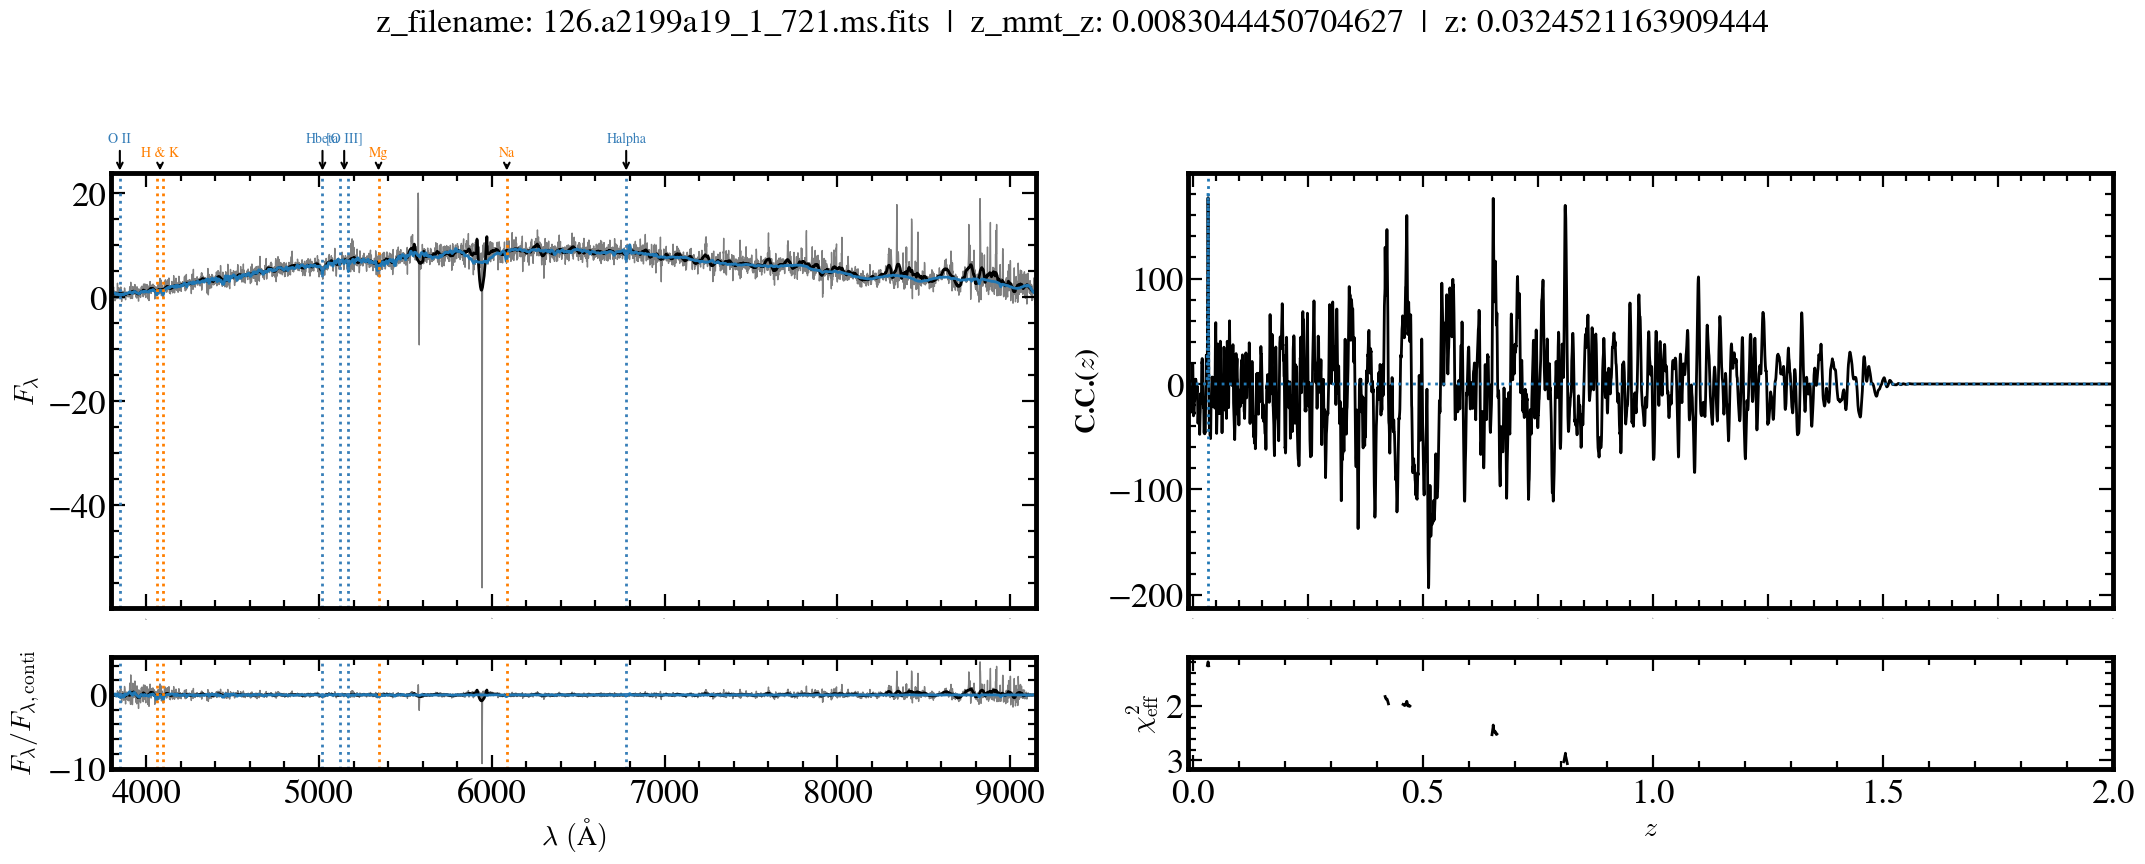

      template_name         z     zerr         r   chi_eff  best  \
0  Late_type_galaxy  0.024309  0.00012  5.930724  1.336008  best   

                          note  
0  possible redshift confusion  
z_filename: 193.a2199a19_1_2535.ms.fits  |  z_mmt_z: 0.3631399559758104  |  z: 0.0243090107493232


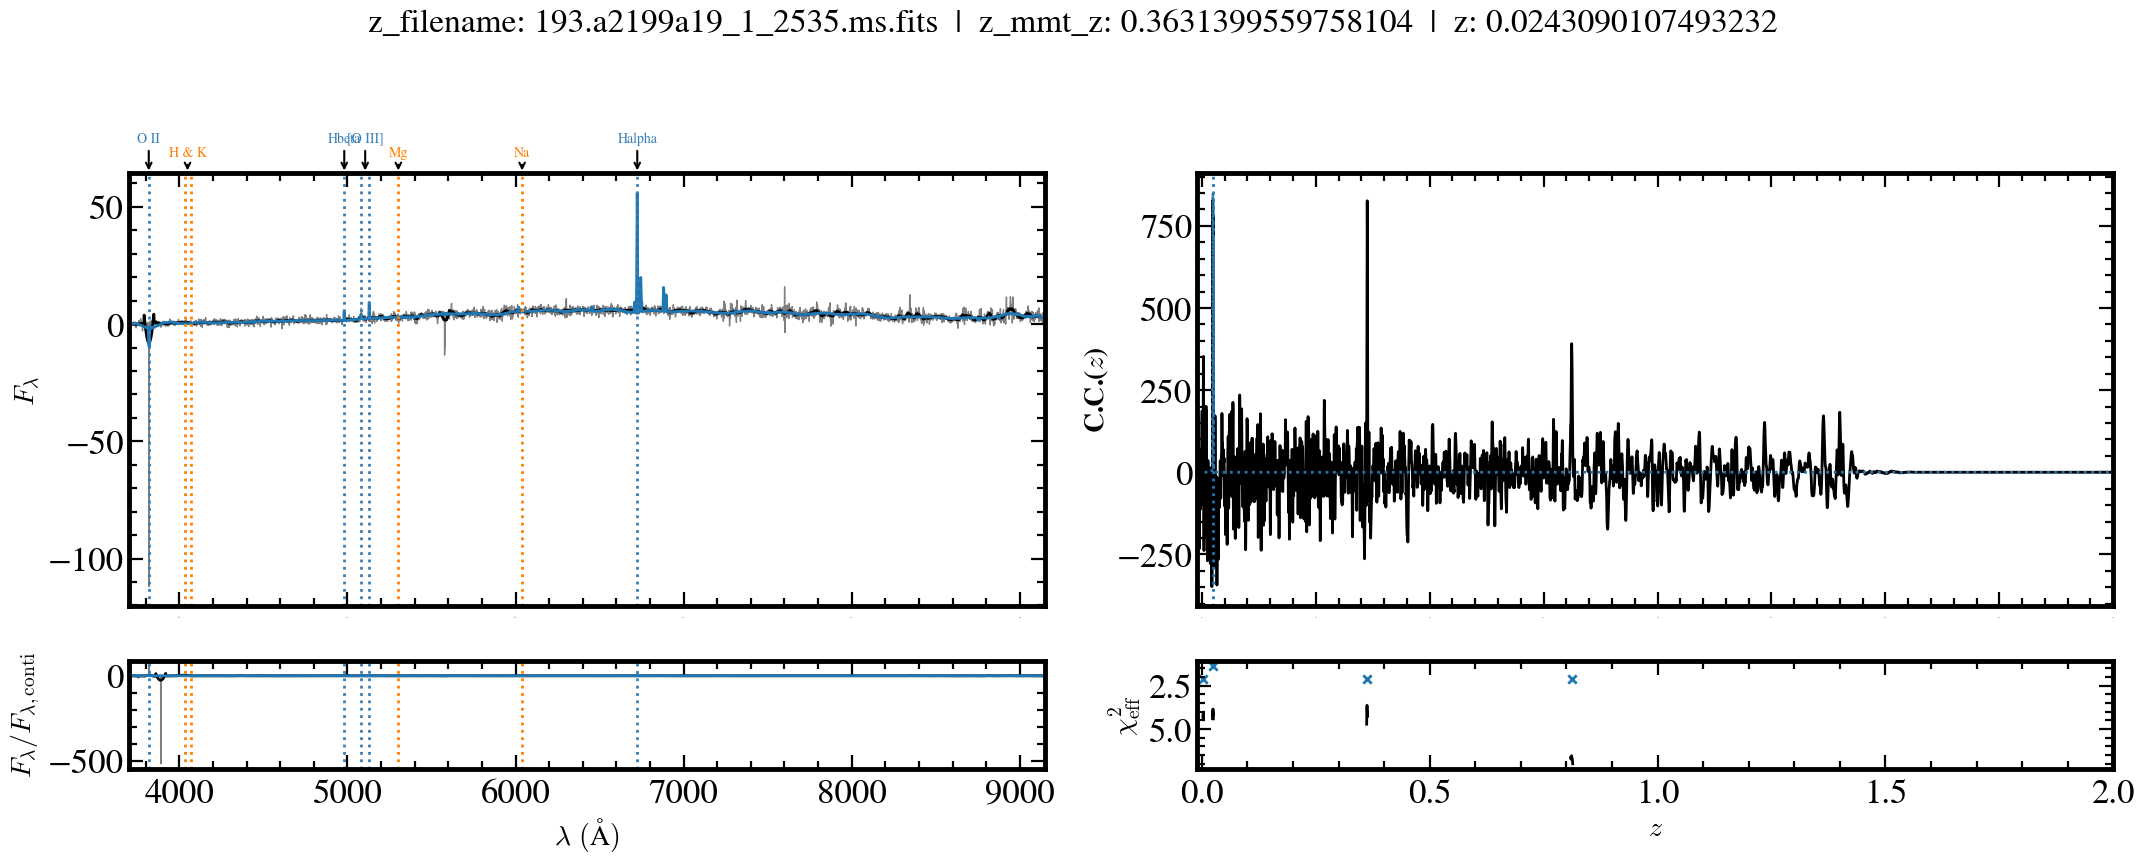

      template_name         z      zerr          r  chi_eff  best  \
0  Late_type_galaxy  0.101293  0.000043  11.180903   1.1271  best   

                          note  
0  possible redshift confusion  
z_filename: 128.a2199a19_1_762.ms.fits  |  z_mmt_z: -0.0272133597170079  |  z: 0.1012933417506287


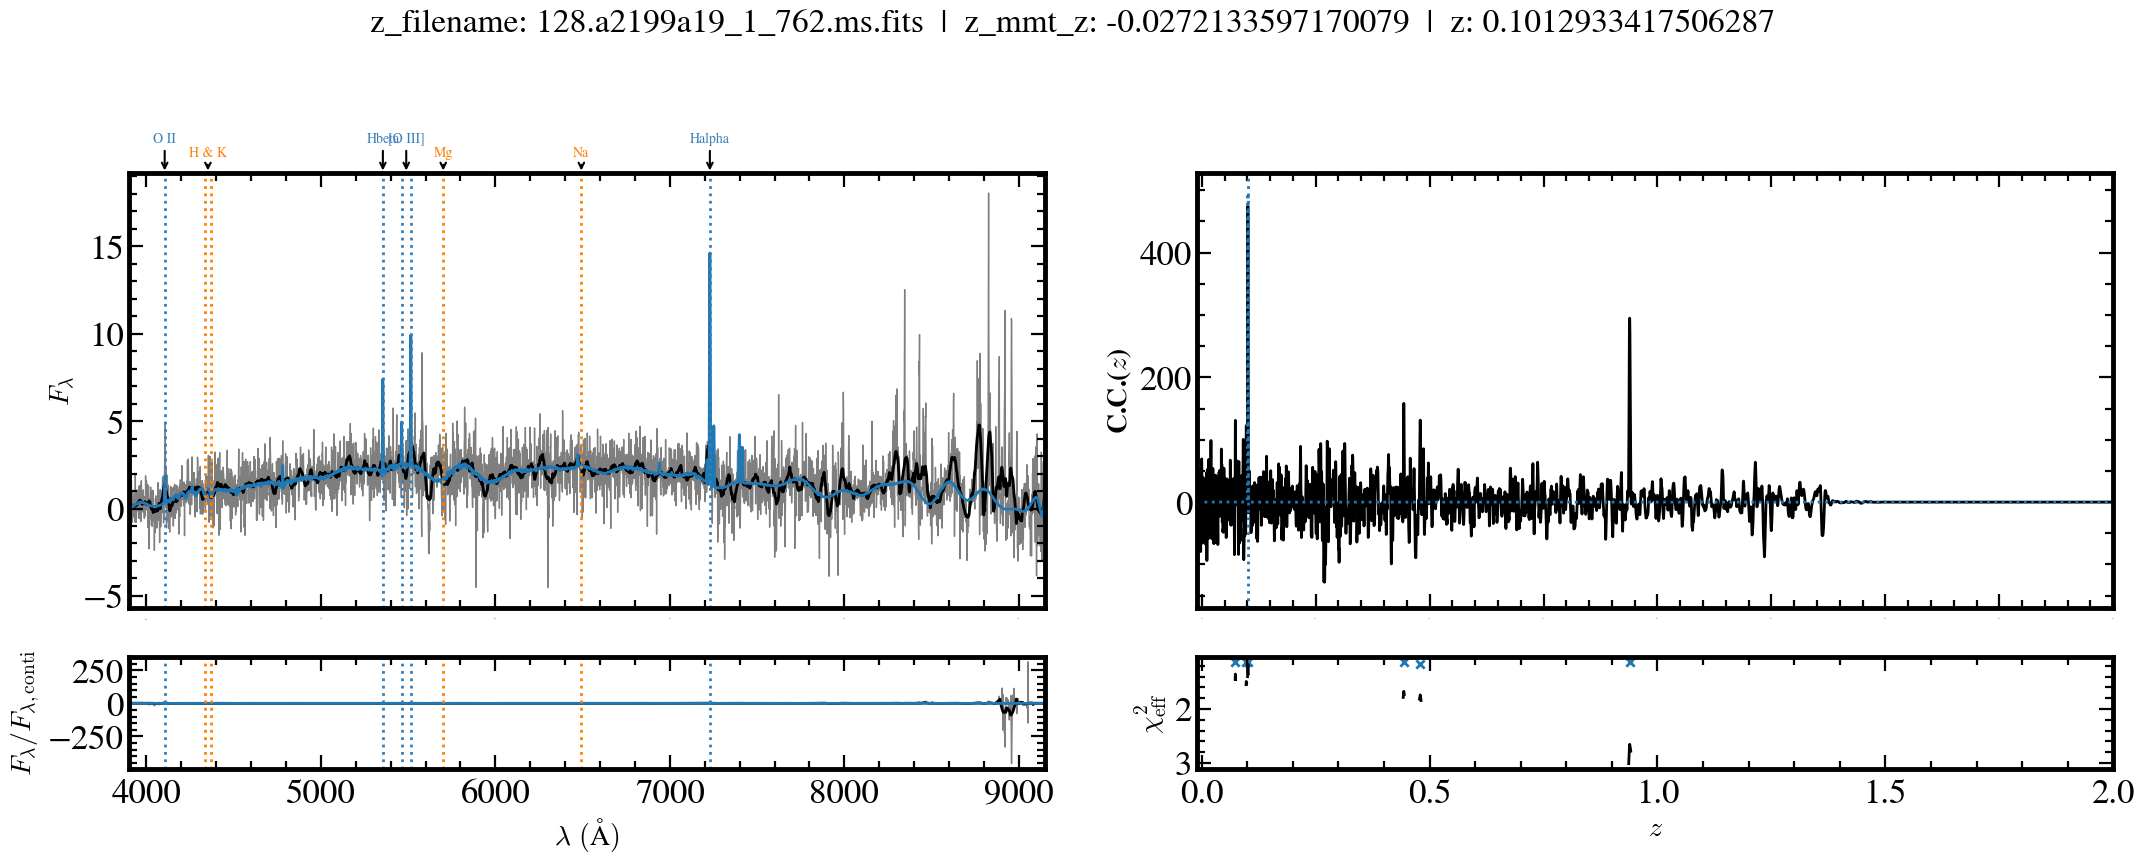

         template_name         z      zerr         r   chi_eff  best  \
0  Luminous_red_galaxy  0.520703  0.000162  6.629896  2.432899  best   
1    Early_type_galaxy  0.520610  0.000142  6.134664  2.921089         

                          note  
0                         good  
1  possible redshift confusion  
z_filename: 233.a2199a19_1_731.ms.fits  |  z_mmt_z: 0.4982032269804466  |  z: 0.5207031175309372


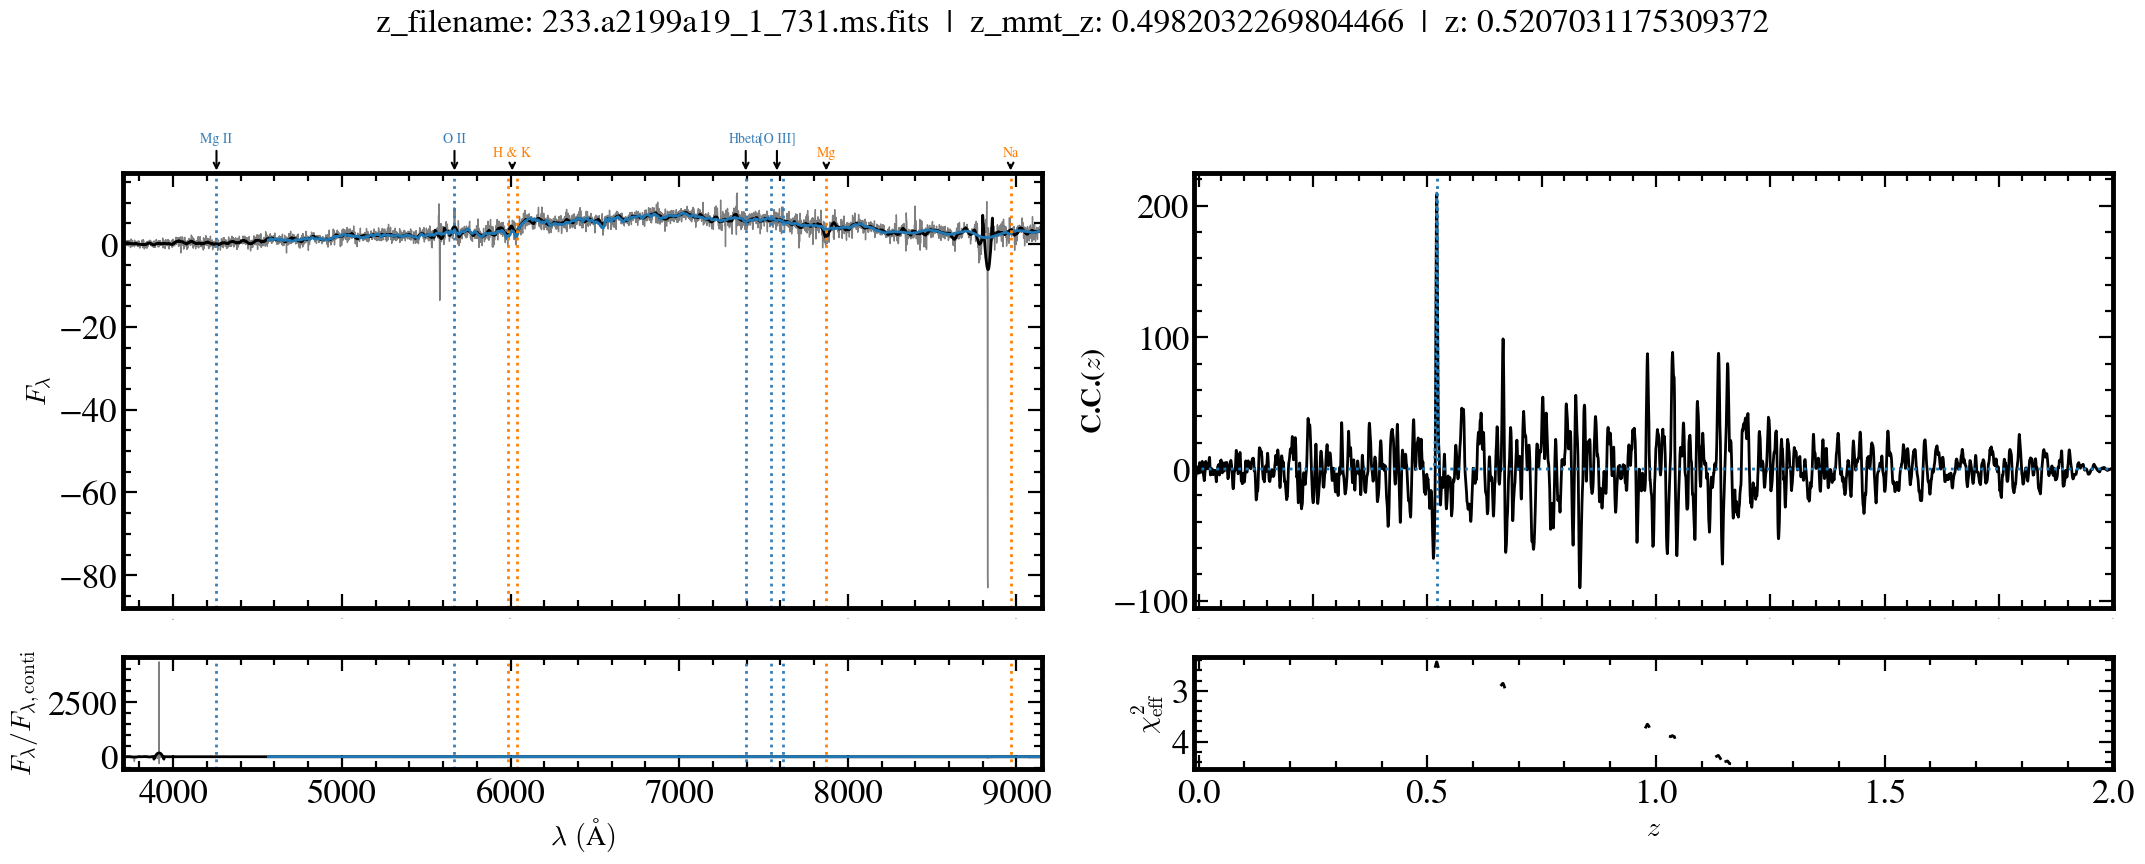

In [8]:
import os
# Set environment variable for RVSNUpy
os.environ["rvsnupy"] = "/Users/jonginpark/my_tools/RVSNUpy"

import matplotlib.pyplot as plt
from RVSNUpy.spectrum_import import MMT_raw
from RVSNUpy.template import sdss_galaxy_templates, zp_calib
from RVSNUpy.rvm import rvm



# Same folder as z_multi cell: basename(z_filename) must match a file here
SPECTRA_DIR = (
    "/Users/jonginpark/sohnix/Research_Archive/2026/Park2026a-A2199-LF/"
    "DATA/A2199/z_A2199_Hwang/z_SPECTRA/skysub_a2199a19_1"
)


def resolve_spec_path(z_filename):
    if pd.isna(z_filename):
        return None
    name = str(z_filename).strip()
    if not name:
        return None
    base = os.path.basename(name)
    full = os.path.join(SPECTRA_DIR, base)
    return full if os.path.isfile(full) else None


def plot_outlier_diagnostics(outlier_df, z_measure):
    """One RVSNUpy diagnostic plot per row of `outlier` (uses z_filename → FITS path)."""
    figures = []
    for _, row in outlier_df.iterrows():
        z_fn = row["z_filename"]
        fits_file = resolve_spec_path(z_fn)
        if fits_file is None:
            print(f"[skip] file not found for z_filename={z_fn!r}")
            continue

        z_mmt = row["z_mmt_z"]
        z_rv = row["z"]

        mmt_spec = MMT_raw(fits_file)
        df_z = z_measure.z_single(mmt_spec)
        print(df_z)

        best_rows = df_z[df_z["best"].astype(str).str.strip() == "best"]
        tname = (
            best_rows["template_name"].iloc[0]
            if len(best_rows)
            else df_z["template_name"].iloc[0]
        )

        template_result = z_measure.cc_result[tname]
        fig, _axes = template_result.diagnostic_plot()
        fig.set_size_inches(22, 9)

        title = f"z_filename: {z_fn}  |  z_mmt_z: {z_mmt}  |  z: {z_rv}"
        fig.suptitle(title, fontsize=24)
        fig.tight_layout(rect=[0, 0, 1, 0.96])

        print(title)
        figures.append(fig)
        plt.show()

    return figures


# Load and calibrate galaxy templates once
gal_templates = zp_calib(sdss_galaxy_templates("vacuum"))
z_measure = rvm(gal_templates)

# All rows in `outlier` (expects columns z_filename, z_mmt_z, z)
figs = plot_outlier_diagnostics(outlier, z_measure)

# 2. Update Redshift in Master catalog

In [9]:
df = pd.read_csv('./A2199_mastercat_intermediate_file1_flag_update.csv')

In [10]:
outlier_updateddf = out[cond1 & cond2][['p_objid', 'z', 'zerr', 'r']]

In [11]:
import pandas as pd

# outlier에 p_objid, z, zerr, r 이 있다고 가정
_update = outlier_updateddf[["p_objid", "z", "zerr", "r"]].drop_duplicates("p_objid", keep="last")
_lookup = _update.set_index("p_objid")

# df 안에서 outlier와 p_objid가 겹치는 행만
m = df["p_objid"].isin(_lookup.index)
pid = df.loc[m, "p_objid"]

df.loc[m, "z_mmt_z"] = pid.map(_lookup["z"])
df.loc[m, "z_mmt_zerr"] = pid.map(_lookup["zerr"])
df.loc[m, "z_mmt_xcr"] = pid.map(_lookup["r"])

df.loc[m, "z_tot_z"] = pid.map(_lookup["z"])
df.loc[m, "z_tot_zerr"] = pid.map(_lookup["zerr"])
df.loc[m, "z_tot_zsource"] = "MMT"

In [12]:
df[df['p_objid'].isin(outlier['p_objid'])]

,phot_source,p_phtype0,p_radgal,p_objid,p_ra,p_dec,p_petromag_u,p_petromagerr_u,p_petromag_g,p_petromagerr_g,p_petromag_r,p_petromagerr_r,p_petromag_i,p_petromagerr_i,p_petromag_z,p_petromagerr_z,p_modelmag_u,p_modelmagerr_u,p_modelmag_g,p_modelmagerr_g,p_modelmag_r,p_modelmagerr_r,p_modelmag_i,p_modelmagerr_i,p_modelmag_z,p_modelmagerr_z,p_fibermag_u,p_fibermagerr_u,p_fibermag_g,p_fibermagerr_g,p_fibermag_r,p_fibermagerr_r,p_fibermag_i,p_fibermagerr_i,p_fibermag_z,p_fibermagerr_z,p_extinction_u,p_extinction_g,p_extinction_r,p_extinction_i,p_extinction_z,p_petrorad_r,p_petroraderr_r,p_devrad_i,p_devab_i,p_run,p_rerun,p_camcol,p_field,p_efac,p_probpsf,z_mmt_xcr,z_mmt_tfilename,z_dfilename,z_filename,z_mmt_z,z_mmt_zerr,z_mmt_velqual,z_ned_name,z_ned_z,z_ned_zerr,z_sdss_z,z_sdss_zerr,z_desi_id,SURVEY,z_desi_z,z_desi_zerr,FLUX_R,FLUX_IVAR_R,z_tot_z,z_tot_zsource,z_tot_zerr,p_modelmag_u_0,p_modelmag_g_0,p_modelmag_r_0,p_modelmag_i_0,p_modelmag_z_0,p_petromag_u_0,p_petromag_g_0,p_petromag_r_0,p_petromag_i_0,p_petromag_z_0,grmod,photflag,galaxyflag,extended_source_flag
3957,DR9,8,16.055414,1237659330315288697,246.908672,39.362998,23.46434,1.971930,21.02931,0.124769,20.19294,0.062751,19.74834,0.070504,20.47955,0.556904,23.11786,0.883347,20.79175,0.044132,20.02462,0.033462,19.65344,0.033123,20.10972,0.225587,22.67456,0.361411,21.07604,0.056881,20.48186,0.031060,20.10671,0.042665,20.23246,0.189165,0.060257,0.044337,0.032157,0.024383,0.017288,1.776838,0.058915,1.311729,0.565204,3226,301,4,100,-0.288914,0,5.979928,/Users/hhwang/Research/Work/MMTraw/2019.0429/r...,skysub_a2199a19_1,126.a2199a19_1_721.ms.fits,0.032452,0.000072,N,NN,-9.0,-9.0,-9.0,-9.0,NN,NaN,-9.0,-9.0,NaN,NaN,0.032452,MMT,0.000072,23.057603,20.747413,19.992463,19.629057,20.092432,23.404083,20.984973,20.160783,19.723957,20.462262,0.754950,0,1,1
5031,DR9,8,19.855655,1237659330852028535,247.008479,39.858933,23.69666,2.304352,22.40129,0.281674,21.20915,0.159163,20.69522,0.146693,20.67649,0.568102,23.40627,0.851565,22.10747,0.122711,21.05911,0.065848,20.52931,0.063780,20.25775,0.173686,22.60875,0.364748,22.39278,0.136731,21.33014,0.086832,20.85724,0.082980,20.34095,0.202989,0.048113,0.035401,0.025676,0.019469,0.013804,1.556678,0.125734,0.717129,0.101120,3226,301,5,98,-0.120985,0,5.930724,/Users/hhwang/Research/Work/MMTraw/2019.0429/r...,skysub_a2199a19_1,193.a2199a19_1_2535.ms.fits,0.024309,0.000120,N,NN,-9.0,-9.0,-9.0,-9.0,NN,NaN,-9.0,-9.0,NaN,NaN,0.024309,MMT,0.000120,23.358157,22.072069,21.033434,20.509841,20.243946,23.648547,22.365889,21.183474,20.675751,20.662686,1.038635,0,1,1
5633,DR9,8,5.664663,1237659326029366062,247.063902,39.488518,24.58895,4.566752,20.39934,0.073247,20.24928,0.079994,20.11639,0.165678,20.23253,0.784034,22.37914,0.453440,20.59124,0.041699,20.27944,0.044906,20.11349,0.064955,20.20225,0.298196,23.20305,0.551171,21.56353,0.045747,21.19569,0.060193,21.03389,0.084491,21.28839,0.460558,0.045291,0.033325,0.024170,0.018327,0.012994,3.131977,0.372061,2.692385,0.764167,3225,301,4,238,-0.946403,0,11.180903,/Users/hhwang/Research/Work/MMTraw/2019.0429/r...,skysub_a2199a19_1,128.a2199a19_1_762.ms.fits,0.101293,0.000043,N,NN,-9.0,-9.0,-9.0,-9.0,NN,NaN,-9.0,-9.0,NaN,NaN,0.101293,MMT,0.000043,22.333849,20.557915,20.255270,20.095163,20.189256,24.543659,20.366015,20.225110,20.098063,20.219536,0.302645,0,1,1
10809,DR9,8,28.315353,1237659326566171775,247.561574,39.904319,23.21896,2.658476,20.96671,0.198629,20.20690,0.119862,19.82421,0.145921,19.23042,0.318026,22.19147,0.469766,21.30935,0.096952,20.06382,0.046238,19.31316,0.041944,18.76002,0.090938,23.07539,0.451482,22.54805,0.130632,21.33787,0.065302,20.58099,0.059448,20.01464,0.126886,0.056180,0.041336,0.029981,0.022733,0.016118,3.789542,0.788418,0.862244,0.905402,3225,301,5,237,-1.130962,0,6.629895,/Users/hhwang/Research/Work/MMTraw/2019.0429/r...,skysub_a2199a19_1,233.a2199a19_1_731.ms.fits,0.520703,0.000162,N,NN,-9.0,-9.0,-9.0,-9.0,NN,NaN,-9.0,-9.0,NaN,NaN,0.520703,MMT,0.000162,22.135290,21.268014,20.033839,19.290427

# 3. Redshift Rounding

In [13]:
import numpy as np

step = 1e-4  # 최소 단위 0.0001

def trunc_with_min_step(series, step=1e-4):
    s = series.astype(float).copy()

    # 1) 자릿수 "끊기" (0.0001 단위로 절삭, 0 방향으로 trunc)
    out = np.trunc(s / step) * step

    # 2) |값|이 0 < |x| < 0.0001 이면 최소 단위로 올림 처리
    small_mask = (s != 0) & (np.abs(s) < step)
    out[small_mask] = np.sign(s[small_mask]) * step

    return out

# 적용
for col in ["z_tot_z", "z_tot_zerr"]:
    df[col] = trunc_with_min_step(df[col], step)

# 보기 좋게 출력
print(df[["z_tot_z", "z_tot_zerr"]].head(20))
print("\nmin abs(z_tot_z) where non-zero:", np.min(np.abs(df.loc[df["z_tot_z"] != 0, "z_tot_z"])))
print("min abs(z_tot_zerr) where non-zero:", np.min(np.abs(df.loc[df["z_tot_zerr"] != 0, "z_tot_zerr"])))

    z_tot_z  z_tot_zerr
0   -9.0000     -9.0000
1   -9.0000     -9.0000
2   -9.0000     -9.0000
3   -9.0000     -9.0000
4   -9.0000     -9.0000
5   -9.0000     -9.0000
6   -9.0000     -9.0000
7   -9.0000     -9.0000
8   -9.0000     -9.0000
9   -9.0000     -9.0000
10  -9.0000     -9.0000
11  -9.0000     -9.0000
12  -9.0000     -9.0000
13   0.6151      0.0002
14  -9.0000     -9.0000
15  -9.0000     -9.0000
16  -9.0000     -9.0000
17  -9.0000     -9.0000
18  -9.0000     -9.0000
19  -9.0000     -9.0000

min abs(z_tot_z) where non-zero: 0.0001
min abs(z_tot_zerr) where non-zero: 0.0001


In [14]:
df.to_csv('A2199_mastercat_intermediate_file2_update_redshift.csv', index=False)